# Last-frame model dRSA after removing the 2250-ms model RDM

This notebook tests whether the model-depth temporal score survives after removing the representational geometry already present 250 ms before the movie's final frame. For each model layer, it computes the 2250-ms and 2500-ms model RDMs across the same stimuli and fits

$$d_{2500} = \alpha + \beta d_{2250} + \varepsilon.$$

The residual RDM vector $\varepsilon$ is then compared with every dynamic-neural RDM time point. The neural data are never residualized. Raw and residualized final-frame timecourses are summarized with the same peak and positive-mass centroid latencies used by the existing presentation analysis, and the **temporal score** is Spearman $\rho$ between normalized layer depth and latency.

Regression is performed across the unique off-diagonal stimulus pairs. With an intercept, the residual is exactly orthogonal to the 2250-ms predictor in Pearson space. Because the configured RSA can be Spearman, the notebook also reports the remaining rank correlation as a diagnostic.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d
from scipy.stats import spearmanr

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path("../..").resolve()

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features,
    match_feature_stimulus_names,
)
from project_specific_utils import (
    compute_rdm_timeseries, cross_temporal_similarity, load_natraster,
    match_timed_static_movie_rasters,
)
from useful_stuff.general_utils import TimeSeries, create_RDM

In [14]:
@dataclass
class Cfg:
    dynamic_exp_name: str = "baby1_260716to24" #"red_20260720to24"
    static_exp_name: str = "baby1_260718to27"#"red_20260726to27"

    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = (84,186) # None
    top_k: int | None = None
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None

    source_neural_fs: float = 1000
    analysis_fs: float = 100
    neural_rdm_metric: str = "cosine_cnt"
    model_rdm_metric: str = "cosine_cnt"
    rsa_metric: str = "spearman"

    model_name: str = "ijepa_vith14_1k" # "dino_v3_h" #
    model_dataset_name: str = "static_dynamic"
    model_pooling: str | None = "mean"
    model_features_dir: Path | None = None

    previous_frame_ms: float = 2250
    last_frame_ms: float = 2500
    regression_fit_intercept: bool = True

    timing_window_ms: tuple[float, float] = (2000, 3000)
    smoothing_sigma_samples: float = 3
    centroid_similarity_cutoff: float = 0.02
    peak_similarity_cutoff: float = 0.02
    linewidth: float = 2
    figure_dpi: int = 120


cfg = Cfg()
if cfg.previous_frame_ms >= cfg.last_frame_ms:
    raise ValueError("previous_frame_ms must precede last_frame_ms.")
# end if frame order is invalid
if not cfg.timing_window_ms[0] <= cfg.last_frame_ms < cfg.timing_window_ms[1]:
    raise ValueError("timing_window_ms must contain last_frame_ms.")
# end if timing window excludes the last frame
if cfg.rsa_metric not in {"correlation", "spearman"}:
    raise ValueError("rsa_metric must be 'correlation' or 'spearman'.")
# end if unsupported RSA metric

model_features_dir = (
    cfg.model_features_dir or Path(paths["data_path"]) / "models"
)
dynamic_path = (
    Path(paths["data_path"]) / "data"
    / f"{cfg.dynamic_exp_name}_natraster_vid.mat"
)
static_path = (
    Path(paths["data_path"]) / "data"
    / f"{cfg.static_exp_name}_natraster_img.mat"
)
cfg

Cfg(dynamic_exp_name='baby1_260716to24', static_exp_name='baby1_260718to27', good_channels=(84, 186), top_k=None, use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, source_neural_fs=1000, analysis_fs=100, neural_rdm_metric='cosine_cnt', model_rdm_metric='cosine_cnt', rsa_metric='spearman', model_name='ijepa_vith14_1k', model_dataset_name='static_dynamic', model_pooling='mean', model_features_dir=None, previous_frame_ms=2250, last_frame_ms=2500, regression_fit_intercept=True, timing_window_ms=(2000, 3000), smoothing_sigma_samples=3, centroid_similarity_cutoff=0.02, peak_similarity_cutoff=0.02, linewidth=2, figure_dpi=120)

## Load and align the dynamic neural responses

The static session is used only to recover the established 100-stimulus matched order. Channel selection is applied identically to the static and movie sessions, while only the movie response enters the analysis.

In [15]:
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / "reliable_channels.yaml"
    )
    reliable_channels_key = (
        cfg.reliable_channels_key or cfg.static_exp_name
    )
# end if cfg.use_reliable_channels

dynamic_loaded, dynamic_names, dynamic_channel_numbers = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
static_loaded, static_names, static_channel_numbers = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(static_channel_numbers, dynamic_channel_numbers):
    raise ValueError("Static and dynamic sessions retained different channels.")
# end if retained channels differ

(
    _, dynamic_rasters, _, _, shared_stimuli, aligned_names,
) = match_timed_static_movie_rasters(
    static_loaded, static_names, dynamic_loaded, dynamic_names,
)

if cfg.top_k is not None:
    if cfg.top_k < 1 or cfg.top_k > dynamic_rasters.shape[0]:
        raise ValueError("top_k must fit inside the retained channel pool.")
    # end if invalid cfg.top_k
    channel_scores = dynamic_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_scores)[-cfg.top_k:][::-1]
else:
    channel_indices = slice(None)
# end if cfg.top_k is not None

selected_channel_numbers = dynamic_channel_numbers[channel_indices]
dynamic_rasters = dynamic_rasters[channel_indices]
dynamic_ts = TimeSeries(dynamic_rasters, fs=cfg.source_neural_fs)
dynamic_ts.resample(cfg.analysis_fs)
dynamic_feature_names = [Path(name).name for name in aligned_names["movie"]]

print(f"Matched stimuli: {len(shared_stimuli)}")
print(f"Selected channels: {len(selected_channel_numbers)}")
print(
    f"Dynamic neural response: {dynamic_ts.shape()} "
    "(channels, time, stimuli)"
)

Matched stimuli: 100
Selected channels: 30
Dynamic neural response: (30, 350, 100) (channels, time, stimuli)


In [16]:
# Compute the dynamic-neural geometry once; every model layer reuses it.
dynamic_neural_rdms = compute_rdm_timeseries(
    dynamic_ts.get_array(), cfg.neural_rdm_metric,
)
dynamic_time_ms = (
    np.arange(dynamic_neural_rdms.shape[0]) * 1000 / dynamic_ts.get_fs()
)
print(
    f"Dynamic neural RDMs: {dynamic_neural_rdms.shape} "
    "(time, stimulus pairs)"
)

Dynamic neural RDMs: (350, 4950) (time, stimulus pairs)


## Residualize the final-frame model geometry

The regression has one observation per unique stimulus pair and is fit independently in every layer. This directly removes the component of the 2500-ms model RDM that is linearly predictable from its own 2250-ms RDM.

In [17]:
"""
regress_out_rdm
Remove one predictor RDM from a target RDM across matched stimulus pairs.

INPUT:
    - target_rdm: np.ndarray -> final-frame vectorized RDM.
    - predictor_rdm: np.ndarray -> earlier-frame vectorized RDM.
    - fit_intercept: bool -> whether to include a constant regression term.

OUTPUT:
    - residual_rdm: np.ndarray -> target variance unexplained by the predictor.
    - regression_summary: dict -> coefficients and variance diagnostics.
"""
def regress_out_rdm(target_rdm, predictor_rdm, fit_intercept=True):
    target_rdm = np.asarray(target_rdm, dtype=float)
    predictor_rdm = np.asarray(predictor_rdm, dtype=float)
    if target_rdm.ndim != 1 or target_rdm.shape != predictor_rdm.shape:
        raise ValueError(
            "target_rdm and predictor_rdm must be matching vectors."
        )
    # end if RDM shapes do not match
    if not np.all(np.isfinite(target_rdm)) or not np.all(
            np.isfinite(predictor_rdm)):
        raise ValueError("RDM regression requires finite distances.")
    # end if an RDM contains non-finite values

    design_columns = [predictor_rdm]
    if fit_intercept:
        design_columns.append(np.ones_like(predictor_rdm))
    # end if fit_intercept
    design_matrix = np.column_stack(design_columns)
    coefficients = np.linalg.lstsq(
        design_matrix, target_rdm, rcond=None,
    )[0]
    predicted_rdm = design_matrix @ coefficients
    residual_rdm = target_rdm - predicted_rdm

    target_variance = np.var(target_rdm)
    residual_variance = np.var(residual_rdm)
    variance_removed = (
        1 - residual_variance / target_variance
        if target_variance > 0 else np.nan
    )
    regression_summary = {
        "beta": coefficients[0],
        "intercept": coefficients[1] if fit_intercept else 0.0,
        "variance_removed": variance_removed,
        "predictor_target_pearson": np.corrcoef(
            predictor_rdm, target_rdm,
        )[0, 1],
        "predictor_residual_pearson": np.corrcoef(
            predictor_rdm, residual_rdm,
        )[0, 1],
        "predictor_target_spearman": spearmanr(
            predictor_rdm, target_rdm,
        ).statistic,
        "predictor_residual_spearman": spearmanr(
            predictor_rdm, residual_rdm,
        ).statistic,
    }
    return residual_rdm, regression_summary
# EOF

In [18]:
feature_paths = list_video_feature_files(
    model_features_dir, cfg.model_name, cfg.model_dataset_name,
    cfg.model_pooling,
)
# Resolve exact HDF5 dataset names once and reuse their matched order.
model_stimulus_names = match_feature_stimulus_names(
    feature_paths[0], dynamic_feature_names,
)

layer_names = []
raw_similarity = []
residual_similarity = []
regression_summaries = []
source_model_fs = None
model_time_ms = None

for feature_path in feature_paths:
    model_features, layer_name, layer_source_fs = (
        load_aligned_video_features(
            feature_path, model_stimulus_names, frame_index=None,
        )
    )
    model_ts = TimeSeries(model_features, fs=layer_source_fs)
    model_ts.resample(cfg.analysis_fs)
    current_model_time_ms = (
        np.arange(len(model_ts)) * 1000 / model_ts.get_fs()
    )
    previous_frame_index = int(np.argmin(
        np.abs(current_model_time_ms - cfg.previous_frame_ms)
    ))
    last_frame_index = int(np.argmin(
        np.abs(current_model_time_ms - cfg.last_frame_ms)
    ))
    if not np.isclose(
            current_model_time_ms[previous_frame_index],
            cfg.previous_frame_ms):
        raise ValueError("The resampled model grid misses previous_frame_ms.")
    # end if previous frame does not lie on model grid
    if not np.isclose(
            current_model_time_ms[last_frame_index], cfg.last_frame_ms):
        raise ValueError("The resampled model grid misses last_frame_ms.")
    # end if last frame does not lie on model grid

    previous_frame_rdm = create_RDM(
        np.ascontiguousarray(
            model_ts.get_array()[:, previous_frame_index, :]
        ),
        metric=cfg.model_rdm_metric,
    )
    last_frame_rdm = create_RDM(
        np.ascontiguousarray(
            model_ts.get_array()[:, last_frame_index, :]
        ),
        metric=cfg.model_rdm_metric,
    )
    residual_rdm, regression_summary = regress_out_rdm(
        last_frame_rdm, previous_frame_rdm,
        fit_intercept=cfg.regression_fit_intercept,
    )

    raw_similarity.append(cross_temporal_similarity(
        dynamic_neural_rdms, last_frame_rdm[np.newaxis, :],
        metric=cfg.rsa_metric,
    )[:, 0])
    residual_similarity.append(cross_temporal_similarity(
        dynamic_neural_rdms, residual_rdm[np.newaxis, :],
        metric=cfg.rsa_metric,
    )[:, 0])
    layer_names.append(layer_name)
    regression_summaries.append(regression_summary)

    if source_model_fs is None:
        source_model_fs = layer_source_fs
        model_time_ms = current_model_time_ms
    elif not np.isclose(source_model_fs, layer_source_fs):
        raise ValueError("Model layers have inconsistent source frame rates.")
    # end if source_model_fs is None
# end for feature_path

raw_similarity = np.stack(raw_similarity, axis=0)
residual_similarity = np.stack(residual_similarity, axis=0)
layer_depths = np.linspace(0, 1, len(layer_names))
print(
    f"Computed {len(layer_names)} layers; model features resampled from "
    f"{source_model_fs:g} to {cfg.analysis_fs:g} Hz"
)
print(
    f"Similarity arrays: {raw_similarity.shape} "
    "(layers, dynamic neural time)"
)

Computed 32 layers; model features resampled from 60 to 100 Hz
Similarity arrays: (32, 350) (layers, dynamic neural time)


Variance removed across layers: mean=0.751, range=(0.657, 0.839)
Maximum |Pearson r| between 2250-ms and residual RDMs: 6.872e-15
Residual Spearman correlation with 2250-ms RDMs: mean=0.055, range=(0.000, 0.200)


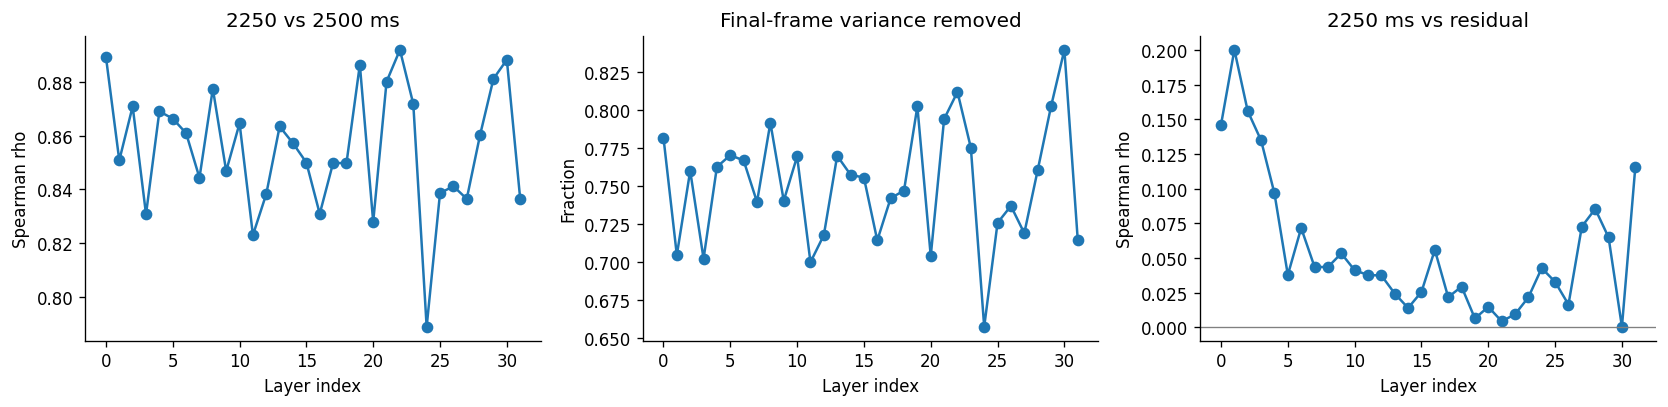

In [19]:
# Inspect how much geometry was removed and whether orthogonality holds.
variance_removed = np.asarray([
    summary["variance_removed"] for summary in regression_summaries
])
predictor_target_spearman = np.asarray([
    summary["predictor_target_spearman"]
    for summary in regression_summaries
])
predictor_residual_pearson = np.asarray([
    summary["predictor_residual_pearson"]
    for summary in regression_summaries
])
predictor_residual_spearman = np.asarray([
    summary["predictor_residual_spearman"]
    for summary in regression_summaries
])

print(
    "Variance removed across layers: "
    f"mean={variance_removed.mean():.3f}, "
    f"range=({variance_removed.min():.3f}, {variance_removed.max():.3f})"
)
print(
    "Maximum |Pearson r| between 2250-ms and residual RDMs: "
    f"{np.max(np.abs(predictor_residual_pearson)):.3e}"
)
print(
    "Residual Spearman correlation with 2250-ms RDMs: "
    f"mean={predictor_residual_spearman.mean():.3f}, "
    f"range=({predictor_residual_spearman.min():.3f}, "
    f"{predictor_residual_spearman.max():.3f})"
)

layer_index = np.arange(len(layer_names))
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), dpi=cfg.figure_dpi)
axes[0].plot(layer_index, predictor_target_spearman, "o-")
axes[0].set(title="2250 vs 2500 ms", ylabel="Spearman rho")
axes[1].plot(layer_index, variance_removed, "o-")
axes[1].set(title="Final-frame variance removed", ylabel="Fraction")
axes[2].plot(layer_index, predictor_residual_spearman, "o-")
axes[2].axhline(0, color="grey", linewidth=0.8)
axes[2].set(title="2250 ms vs residual", ylabel="Spearman rho")
for axis in axes:
    axis.set_xlabel("Layer index")
    axis.spines[["top", "right"]].set_visible(False)
# end for axis
fig.tight_layout()

## Recompute the last-frame similarity timecourses and temporal scores

Timing is measured only inside `cfg.timing_window_ms`. Curves are smoothed for timing estimation, then values below the configured cutoff and all negative values receive zero weight. Latency is expressed relative to the 2500-ms final-frame onset.

In [20]:
"""
summarize_layer_timing
Compute smoothed curves plus centroid and peak latency for every model layer.

INPUT:
    - similarity: np.ndarray -> layers x dynamic-neural-time RSA values.
    - time_ms: np.ndarray -> dynamic neural time coordinate.
    - cfg: Cfg -> timing window, smoothing, cutoff, and frame onset.

OUTPUT:
    - smoothed_similarity: np.ndarray -> curves used for timing summaries.
    - centroid_latency_ms: np.ndarray -> positive-mass centroid minus frame onset.
    - peak_latency_ms: np.ndarray -> positive peak time minus frame onset.
"""
def summarize_layer_timing(similarity, time_ms, cfg):
    smoothed_similarity = gaussian_filter1d(
        similarity, sigma=cfg.smoothing_sigma_samples, axis=1,
    )
    window_mask = (
        (time_ms >= cfg.timing_window_ms[0])
        & (time_ms < cfg.timing_window_ms[1])
    )
    if not window_mask.any():
        raise ValueError("timing_window_ms contains no neural samples.")
    # end if timing window is empty
    window_time_ms = time_ms[window_mask]
    centroid_latency_ms = []
    peak_latency_ms = []

    for layer_curve in smoothed_similarity:
        window_curve = layer_curve[window_mask]
        centroid_weights = np.where(
            np.isfinite(window_curve)
            & (window_curve > cfg.centroid_similarity_cutoff),
            window_curve, 0,
        )
        peak_values = np.where(
            np.isfinite(window_curve)
            & (window_curve > cfg.peak_similarity_cutoff),
            window_curve, 0,
        )

        if centroid_weights.sum() > 0:
            centroid_time_ms = np.average(
                window_time_ms, weights=centroid_weights,
            )
            centroid_latency_ms.append(
                centroid_time_ms - cfg.last_frame_ms
            )
        else:
            centroid_latency_ms.append(np.nan)
        # end if centroid mass exists

        if peak_values.sum() > 0:
            peak_time_ms = window_time_ms[np.argmax(peak_values)]
            peak_latency_ms.append(peak_time_ms - cfg.last_frame_ms)
        else:
            peak_latency_ms.append(np.nan)
        # end if positive peak exists
    # end for layer_curve

    return (
        smoothed_similarity, np.asarray(centroid_latency_ms),
        np.asarray(peak_latency_ms),
    )
# EOF

(
    raw_smoothed, raw_centroid_latency_ms, raw_peak_latency_ms,
) = summarize_layer_timing(raw_similarity, dynamic_time_ms, cfg)
(
    residual_smoothed, residual_centroid_latency_ms,
    residual_peak_latency_ms,
) = summarize_layer_timing(residual_similarity, dynamic_time_ms, cfg)

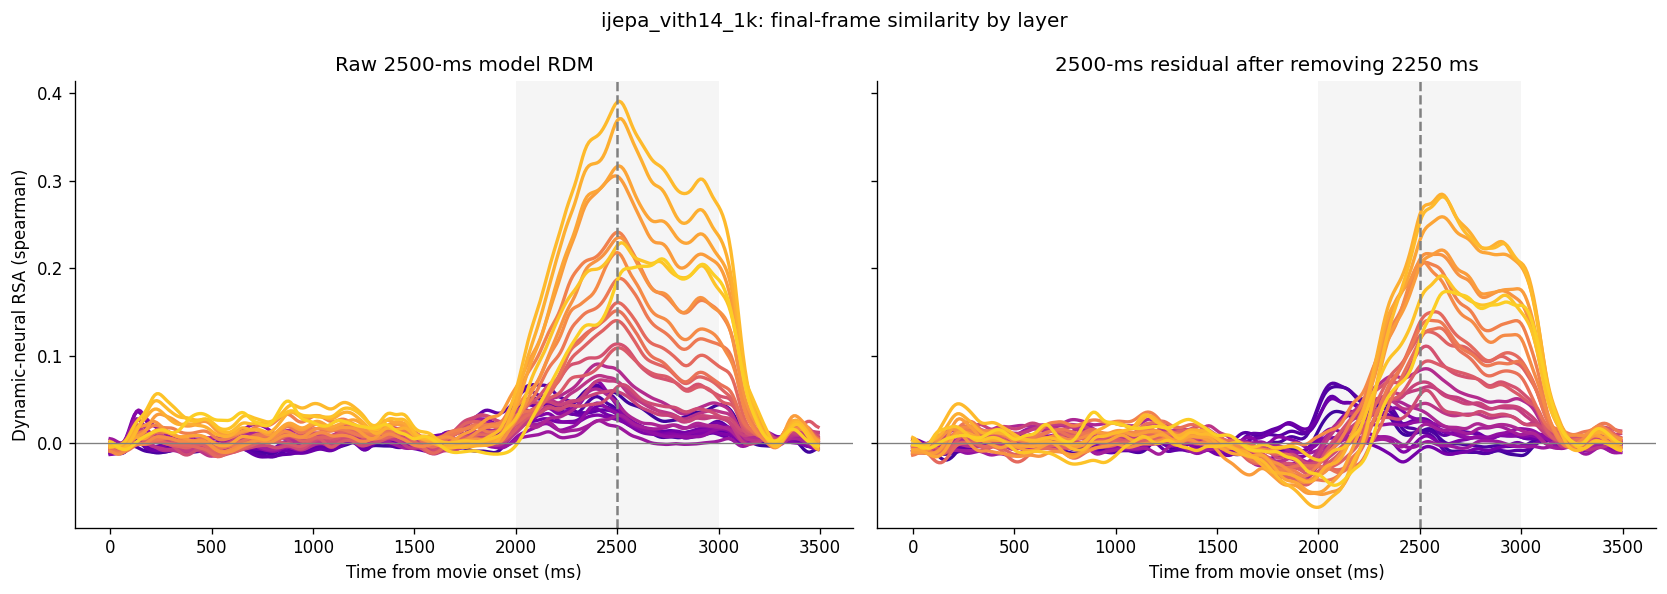

In [21]:
layer_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(layer_names)))
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), sharex=True, sharey=True, dpi=cfg.figure_dpi,
)
for layer_index, layer_name in enumerate(layer_names):
    axes[0].plot(
        dynamic_time_ms, raw_smoothed[layer_index],
        color=layer_colors[layer_index], linewidth=cfg.linewidth,
    )
    axes[1].plot(
        dynamic_time_ms, residual_smoothed[layer_index],
        color=layer_colors[layer_index], linewidth=cfg.linewidth,
    )
# end for layer_index, layer_name

for axis in axes:
    axis.axhline(0, color="grey", linewidth=0.8)
    axis.axvline(cfg.last_frame_ms, color="grey", linestyle="--")
    axis.axvspan(
        *cfg.timing_window_ms, color="grey", alpha=0.08, linewidth=0,
    )
    axis.set_xlabel("Time from movie onset (ms)")
    axis.spines[["top", "right"]].set_visible(False)
# end for axis
axes[0].set(
    title="Raw 2500-ms model RDM",
    ylabel=f"Dynamic-neural RSA ({cfg.rsa_metric})",
)
axes[1].set(title="2500-ms residual after removing 2250 ms")
fig.suptitle(f"{cfg.model_name}: final-frame similarity by layer")
fig.tight_layout()

Text(0.5, 0.98, 'ijepa_vith14_1k: final-frame representational timecourse')

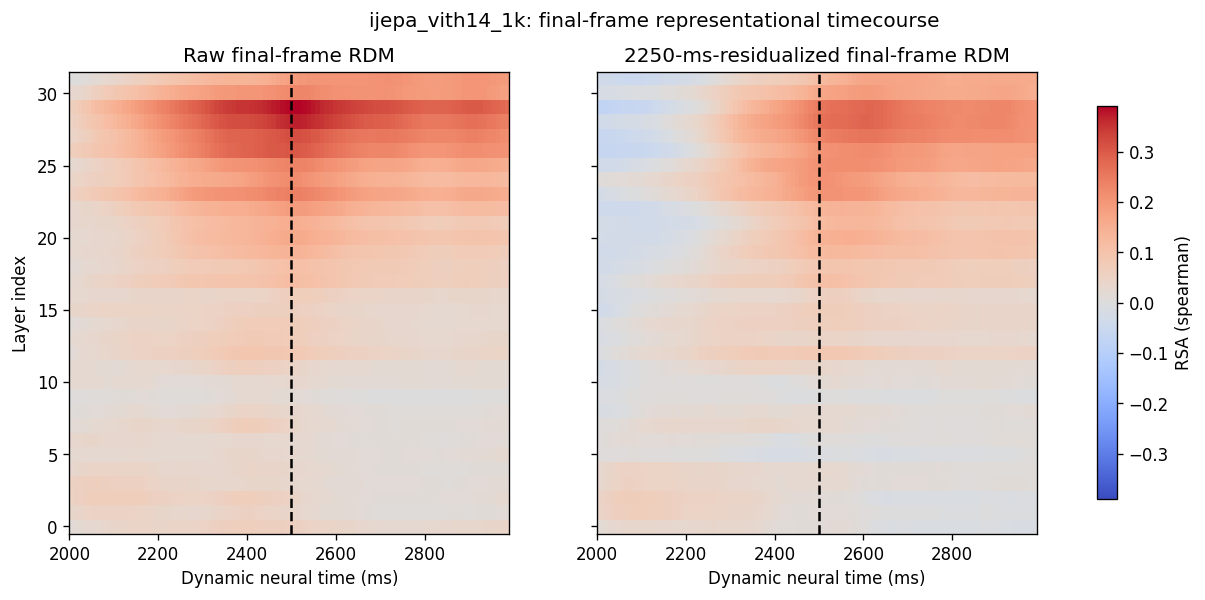

In [22]:
# A layer-by-time view makes any depth-dependent temporal progression visible.
plot_mask = (
    (dynamic_time_ms >= cfg.timing_window_ms[0])
    & (dynamic_time_ms < cfg.timing_window_ms[1])
)
color_limit = np.nanmax(np.abs(np.concatenate([
    raw_smoothed[:, plot_mask].ravel(),
    residual_smoothed[:, plot_mask].ravel(),
])))
fig, axes = plt.subplots(
    1, 2, figsize=(13, 5), sharex=True, sharey=True, dpi=cfg.figure_dpi,
)
for axis, values, title in zip(
        axes,
        (raw_smoothed, residual_smoothed),
        ("Raw final-frame RDM", "2250-ms-residualized final-frame RDM"),
        ):
    image = axis.imshow(
        values[:, plot_mask], aspect="auto", origin="lower",
        cmap="coolwarm", vmin=-color_limit, vmax=color_limit,
        extent=(
            dynamic_time_ms[plot_mask][0], dynamic_time_ms[plot_mask][-1],
            -0.5, len(layer_names) - 0.5,
        ),
    )
    axis.axvline(cfg.last_frame_ms, color="black", linestyle="--")
    axis.set(title=title, xlabel="Dynamic neural time (ms)")
# end for axis, values, title
axes[0].set_ylabel("Layer index")
fig.colorbar(
    image, ax=axes, label=f"RSA ({cfg.rsa_metric})", shrink=0.85,
)
fig.suptitle(f"{cfg.model_name}: final-frame representational timecourse")

In [23]:
timing_values = {
    "raw": {
        "centroid": raw_centroid_latency_ms,
        "peak": raw_peak_latency_ms,
    },
    "residual": {
        "centroid": residual_centroid_latency_ms,
        "peak": residual_peak_latency_ms,
    },
}
temporal_scores = {}
for condition_name, condition_values in timing_values.items():
    temporal_scores[condition_name] = {}
    for timing_name, latency_ms in condition_values.items():
        valid_layers = np.isfinite(latency_ms)
        if valid_layers.sum() < 2:
            score = np.nan
            pvalue = np.nan
        else:
            score_result = spearmanr(
                layer_depths[valid_layers], latency_ms[valid_layers],
            )
            score = score_result.statistic
            pvalue = score_result.pvalue
        # end if fewer than two valid layers
        temporal_scores[condition_name][timing_name] = {
            "rho": score, "pvalue": pvalue,
            "n_layers": int(valid_layers.sum()),
        }
    # end for timing_name, latency_ms
# end for condition_name, condition_values

for condition_name in ("raw", "residual"):
    for timing_name in ("centroid", "peak"):
        result = temporal_scores[condition_name][timing_name]
        print(
            f"{condition_name:8s} {timing_name:8s}: "
            f"rho={result['rho']:.3f}, p={result['pvalue']:.3g}, "
            f"n={result['n_layers']}"
        )
    # end for timing_name
# end for condition_name

raw      centroid: rho=0.926, p=2.96e-14, n=32
raw      peak    : rho=0.838, p=2.16e-09, n=32
residual centroid: rho=0.935, p=1.14e-13, n=29
residual peak    : rho=0.889, p=1.24e-10, n=29


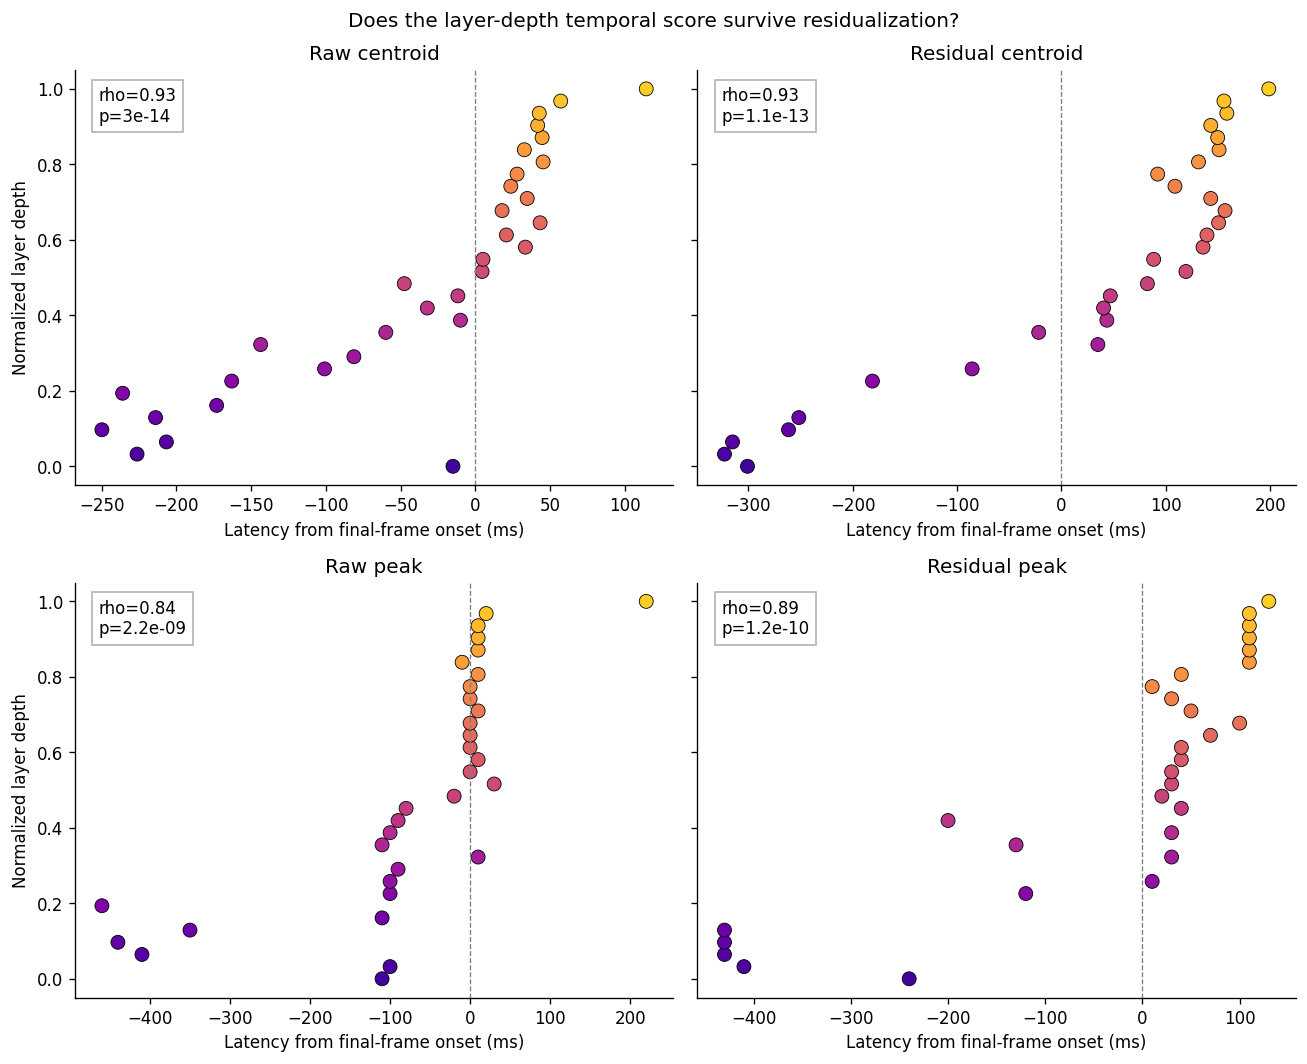

In [24]:
fig, axes = plt.subplots(
    2, 2, figsize=(11, 9), sharey=True, dpi=cfg.figure_dpi,
)
for row_index, timing_name in enumerate(("centroid", "peak")):
    for column_index, condition_name in enumerate(("raw", "residual")):
        axis = axes[row_index, column_index]
        latency_ms = timing_values[condition_name][timing_name]
        valid_layers = np.isfinite(latency_ms)
        score = temporal_scores[condition_name][timing_name]
        axis.scatter(
            latency_ms[valid_layers], layer_depths[valid_layers],
            c=layer_colors[valid_layers], s=70, edgecolors="black",
            linewidths=0.5,
        )
        axis.axvline(0, color="grey", linestyle="--", linewidth=0.8)
        axis.text(
            0.04, 0.96,
            f"rho={score['rho']:.2f}\np={score['pvalue']:.2g}",
            transform=axis.transAxes, ha="left", va="top",
            bbox={"facecolor": "white", "edgecolor": "0.7"},
        )
        axis.set(
            title=f"{condition_name.capitalize()} {timing_name}",
            xlabel="Latency from final-frame onset (ms)",
        )
        axis.spines[["top", "right"]].set_visible(False)
    # end for column_index, condition_name
    axes[row_index, 0].set_ylabel("Normalized layer depth")
# end for row_index, timing_name
fig.suptitle("Does the layer-depth temporal score survive residualization?")
fig.tight_layout()

Temporal-score comparison
Centroid: raw rho=0.813 (p=1.53e-08); residual rho=0.850 (p=1.5e-09)
Peak: raw rho=0.795 (p=5.58e-08); residual rho=0.907 (p=2.08e-12)


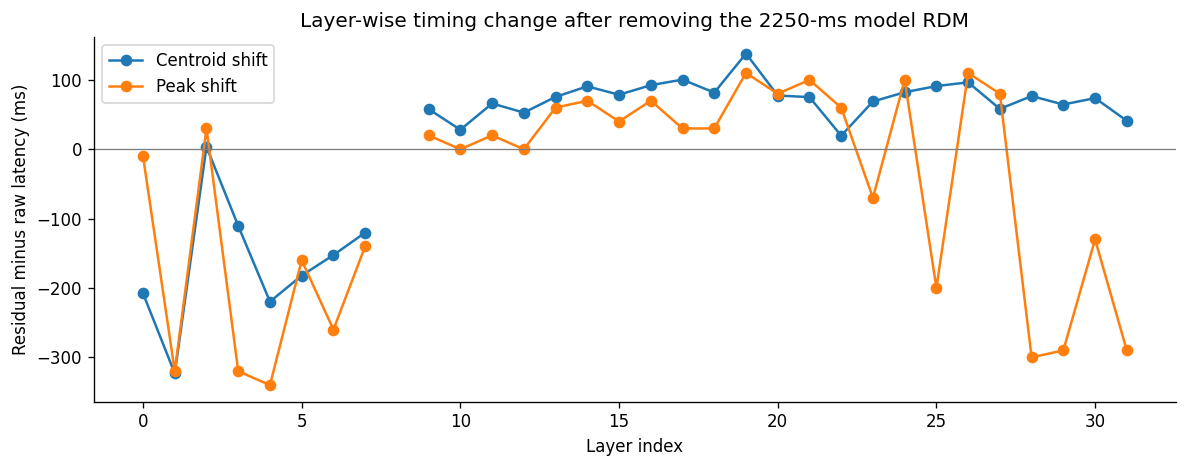

In [13]:
# Report the change in each timing measure without hiding layer-level effects.
centroid_shift_ms = (
    residual_centroid_latency_ms - raw_centroid_latency_ms
)
peak_shift_ms = residual_peak_latency_ms - raw_peak_latency_ms
layer_indices = np.arange(len(layer_names))

fig, axis = plt.subplots(figsize=(10, 4), dpi=cfg.figure_dpi)
axis.plot(layer_indices, centroid_shift_ms, "o-", label="Centroid shift")
axis.plot(layer_indices, peak_shift_ms, "o-", label="Peak shift")
axis.axhline(0, color="grey", linewidth=0.8)
axis.set(
    xlabel="Layer index", ylabel="Residual minus raw latency (ms)",
    title="Layer-wise timing change after removing the 2250-ms model RDM",
)
axis.legend()
axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

raw_centroid_score = temporal_scores["raw"]["centroid"]
residual_centroid_score = temporal_scores["residual"]["centroid"]
raw_peak_score = temporal_scores["raw"]["peak"]
residual_peak_score = temporal_scores["residual"]["peak"]

print("Temporal-score comparison")
print(
    f"Centroid: raw rho={raw_centroid_score['rho']:.3f} "
    f"(p={raw_centroid_score['pvalue']:.3g}); residual rho="
    f"{residual_centroid_score['rho']:.3f} "
    f"(p={residual_centroid_score['pvalue']:.3g})"
)
print(
    f"Peak: raw rho={raw_peak_score['rho']:.3f} "
    f"(p={raw_peak_score['pvalue']:.3g}); residual rho="
    f"{residual_peak_score['rho']:.3f} "
    f"(p={residual_peak_score['pvalue']:.3g})"
)

## Interpretation

The key comparison is the final printed block and the four depth-versus-latency panels. A temporal score **holds** after control when the residual centroid or peak latency still increases monotonically with layer depth (positive $\rho$) and the corresponding evidence remains convincing. If the raw score is positive but the residual score approaches zero or reverses, the original effect was largely carried by representational geometry already present at 2250 ms.

The residualization diagnostic should show Pearson correlations numerically near zero. A remaining Spearman correlation is possible because the OLS regression removes linear variance in raw RDM-distance space, whereas the final RSA is rank-based when `cfg.rsa_metric="spearman"`. Set `rsa_metric="correlation"` if the desired inferential test should stay entirely in the same linear space.